In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset

In [2]:
dataset = load_dataset('dair-ai/emotion')
dataset

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [3]:
train_text = dataset['train']['text']
train_text


Column(['i didnt feel humiliated', 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake', 'im grabbing a minute to post i feel greedy wrong', 'i am ever feeling nostalgic about the fireplace i will know that it is still on the property', 'i am feeling grouchy'])

In [4]:
train_label= dataset['train']['label']
train_label

Column([0, 0, 3, 2, 3])

In [5]:
test_text = dataset['test']['text']
test_text

Column(['im feeling rather rotten so im not very ambitious right now', 'im updating my blog because i feel shitty', 'i never make her separate from me because i don t ever want her to feel like i m ashamed with her', 'i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived', 'i was feeling a little vain when i did this one'])

In [6]:
test_label = dataset['test']['label']
test_label

Column([0, 0, 0, 1, 0])

In [7]:
label_names = dataset['train'].features['label'].names
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [8]:
df_train = pd.DataFrame({
    'text'   : train_text,
    'label'  : [label_names[i] for i in train_label]
})
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [9]:
df_test = pd.DataFrame({
    'test'  :test_text,
    'label' :[label_names[i] for i in test_label]
})

df_test.head()

,test,label
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


In [10]:
df_train.isnull().sum()

,0
text,0
label,0


In [11]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    16000 non-null  object
 1   label   16000 non-null  object
dtypes: object(2)
memory usage: 250.1+ KB


In [12]:
df_train.duplicated().sum()

np.int64(1)

In [13]:
df_train.drop_duplicates(inplace=True)

In [14]:
df_train.duplicated().sum()

np.int64(0)

In [15]:
df_train.shape

(15999, 2)

In [16]:
df_train.label.value_counts().index

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='object', name='label')

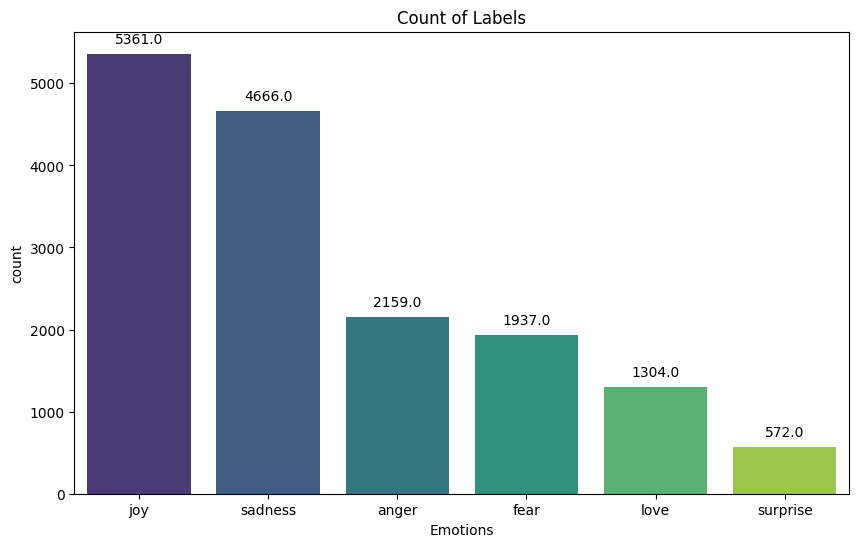

In [17]:
plt.figure(figsize=(10,6))
ex = sns.countplot(x = 'label', data = df_train, palette='viridis',order = df_train.label.value_counts().index)
plt.title("Count of Labels")
plt.xlabel("Emotions")
plt.ylabel("count")

for p in ex.patches:
    ex.annotate(p.get_height(), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 10),
                textcoords = 'offset points')
plt.show()

In [18]:
import re
import string

In [19]:
def preprocess(text):
  text = text.lower()
  text = text.translate(str.maketrans('','',string.punctuation))
  return text

train_text = df_train['text'].apply(preprocess)
train_text.head()


,text
0,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy


In [20]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [21]:
maxlen = 0
for i in train_text:
  if len(i.split()) > maxlen:
    maxlen = len(i.split())
print(f"Maximum sentence length: {maxlen}")

Maximum sentence length: 66


In [22]:
max_words = 10000

tokenizer = Tokenizer(num_words = max_words, oov_token = '<OOV>')
tokenizer.fit_on_texts(df_train['text'])

train_sequences = tokenizer.texts_to_sequences(df_train['text'])
test_sequences = tokenizer.texts_to_sequences(df_test['test'])

padded_train_sequences = pad_sequences(train_sequences,maxlen = 66,padding="post",truncating="post")
padded_test_sequences = pad_sequences(test_sequences,maxlen = 66,padding="post",truncating="post")

In [23]:
print(f"vocabulary size : {len(tokenizer.word_index)}")

vocabulary size : 15213


In [24]:
padded_train_sequences

array([[   2,  139,    3, ...,    0,    0,    0],
       [   2,   40,  101, ...,    0,    0,    0],
       [  17, 3060,    7, ...,    0,    0,    0],
       ...,
       [   2,    3,  327, ...,    0,    0,    0],
       [   2,    3,   14, ...,    0,    0,    0],
       [   2,   47,    7, ...,    0,    0,    0]], dtype=int32)

In [25]:
train_labels = np.array([label_names.index(label) for label in df_train['label']])

from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(train_labels),
    y = train_labels
)
class_weight_dict = dict(enumerate(class_weights))

train_labels

array([0, 0, 3, ..., 1, 3, 0])

In [26]:
test_labels = np.array(test_label)
test_labels

array([0, 0, 0, ..., 1, 1, 4])

In [27]:
num_classes = len(np.unique(train_labels))
num_classes

6

In [28]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(train_labels),
    y = train_labels
)



In [29]:
# class_weight_dict is now calculated in cell ePw-oM0S9ozP to ensure consistency.

In [30]:
from sys import monitoring
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss',patience=7,restore_best_weights=True)

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,Dense,Dropout,LSTM,GRU

In [32]:
rnn_model = Sequential([
    Embedding(input_dim = max_words,output_dim = 128, input_length = 66),
    SimpleRNN(units = 12, return_sequences=True),
    Dropout(0.2),
    SimpleRNN(units = 64),
    Dropout(0.2),
    Dense(units=num_classes,activation='softmax'),
])


In [33]:
rnn_model.compile(optimizer='adam',loss = 'sparse_categorical_crossentropy',metrics=['accuracy'])

In [34]:
rnn_model.fit(
    padded_train_sequences,
    train_labels,
    epochs = 20,
    batch_size = 32,
    callbacks = [early_stopping],
    class_weight = class_weight_dict,
    validation_data = (padded_test_sequences, test_labels) # Added validation data
)

rnn_lose,rnn_acc = rnn_model.evaluate(padded_test_sequences,test_labels)
print(f"Test Loss: {rnn_lose}")
print(f"Test Accuracy: {rnn_acc}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.1539 - loss: 1.8152 - val_accuracy: 0.1190 - val_loss: 1.8204
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.1822 - loss: 1.7842 - val_accuracy: 0.2360 - val_loss: 1.7876
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.2006 - loss: 1.7431 - val_accuracy: 0.1275 - val_loss: 1.8650
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.2646 - loss: 1.5965 - val_accuracy: 0.1590 - val_loss: 1.8591
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.3956 - loss: 1.3292 - val_accuracy: 0.1845 - val_loss: 2.0312
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5055 - loss: 1.0862 - val_accuracy: 0.1970 - val_loss: 2.1315
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.5865 - loss: 0.9191 - val_accuracy: 0.2055 - val_loss: 2.3497
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.6407 - loss: 0.7936 - val_a

In [35]:
lstm_model = Sequential([
    Embedding(input_dim = max_words,output_dim = 128, input_length = 66),
    LSTM(units = 128,return_sequences=True),
    Dropout(0.2),
    LSTM(units = 64),
    Dropout(0.2),
    Dense(units=num_classes,activation='softmax'),
])

In [36]:
lstm_model.compile(optimizer = 'adam',loss = 'sparse_categorical_crossentropy',metrics=['accuracy'])

In [37]:
lstm_model.fit(
    padded_train_sequences,
    train_labels,
    epochs = 20,
    batch_size = 32,
    validation_data = (padded_test_sequences, test_labels),
    callbacks = [early_stopping],
    class_weight = class_weight_dict
)

lstm_loss,lstm_Acc = lstm_model.evaluate(padded_test_sequences,test_labels)
print(f"Test Loss: {lstm_loss}")
print(f"Test Accuracy: {lstm_Acc}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.1409 - loss: 1.7937 - val_accuracy: 0.1120 - val_loss: 1.7938
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1793 - loss: 1.7934 - val_accuracy: 0.0330 - val_loss: 1.8328
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.1568 - loss: 1.7930 - val_accuracy: 0.0795 - val_loss: 1.8062
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1769 - loss: 1.7927 - val_accuracy: 0.2905 - val_loss: 1.7850
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.1705 - loss: 1.7924 - val_accuracy: 0.1120 - val_loss: 1.7965
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1271 - loss: 1.7925 - val_accuracy: 0.1375 - val_loss: 1.7915
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.1603 - loss: 1.7928 - val_accuracy: 0.0330 - val_loss: 1.8003
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.1106 - loss: 1.7919 - val_acc

In [38]:
gru_model = Sequential([
    Embedding(input_dim = max_words,output_dim = 128, input_length = 66),
    GRU(units = 128,return_sequences=True),
    Dropout(0.2),
    GRU(units = 64),
    Dropout(0.2),
    Dense(units=num_classes,activation='softmax'),
])

In [39]:
gru_model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy',metrics=['accuracy'])

In [40]:
gru_model.fit(
    padded_train_sequences,
    train_labels,
    epochs = 20,
    batch_size = 32,
    validation_data = (padded_test_sequences, test_labels),
    callbacks = [early_stopping],
    class_weight = class_weight_dict
)

gru_loss,gru_acc = gru_model.evaluate(padded_test_sequences,test_labels)
print(f"Test Loss: {gru_loss}")
print(f"Test Accuracy: {gru_acc}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.1332 - loss: 1.7948 - val_accuracy: 0.3475 - val_loss: 1.7833
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1408 - loss: 1.7934 - val_accuracy: 0.2905 - val_loss: 1.7872
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.1248 - loss: 1.7938 - val_accuracy: 0.1375 - val_loss: 1.7824
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1351 - loss: 1.7931 - val_accuracy: 0.2905 - val_loss: 1.7858
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.1788 - loss: 1.7931 - val_accuracy: 0.1375 - val_loss: 1.7962
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1470 - loss: 1.7932 - val_accuracy: 0.3475 - val_loss: 1.7821
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.1695 - loss: 1.7930 - val_accuracy: 0.1375 - val_loss: 1.7917
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3475 - loss: 1.7833
Test Loss: 1.78333568572

In [41]:
result_df = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_lose, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_acc, lstm_Acc, gru_acc]
})

result_df

,Model,Test Loss,Test Accuracy
0,RNN,1.787640,0.2360
1,LSTM,0.661129,0.8215
2,GRU,1.783336,0.3475


In [42]:
from tensorflow.keras.layers import Bidirectional

In [43]:
BiGRU = Sequential([
    Embedding(input_dim = max_words,output_dim = 300, input_length = 66),
    Bidirectional(GRU(units = 128,return_sequences=True)),
    Dropout(0.2),
    Bidirectional(GRU(units = 64)),
    Dropout(0.2),
    Dense(units=num_classes,activation='softmax'),
])


BiGRU.compile(optimizer = 'adam',loss = 'sparse_categorical_crossentropy',metrics=['accuracy'])

In [44]:
BiGRU.fit(
    padded_train_sequences,
    train_labels,
    epochs = 20,
    batch_size = 32,
    validation_data = (padded_test_sequences, test_labels),
    class_weight = class_weight_dict,
    callbacks = [early_stopping],
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.5908 - loss: 0.9222 - val_accuracy: 0.8905 - val_loss: 0.3042
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9250 - loss: 0.1963 - val_accuracy: 0.9235 - val_loss: 0.2144
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9472 - loss: 0.1286 - val_accuracy: 0.9185 - val_loss: 0.1994
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9635 - loss: 0.0922 - val_accuracy: 0.9240 - val_loss: 0.1883
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9766 - loss: 0.0618 - val_accuracy: 0.9225 - val_loss: 0.2204
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9791 - loss: 0.0541 - val_accuracy: 0.9190 - val_loss: 0.2554
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9854 - loss: 0.0398 - val_accuracy: 0.9195 - val_loss: 0.2840
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9849 - loss: 0.0395 - val

In [45]:
BiGRU_loss,BiGRU_acc  = BiGRU.evaluate(padded_test_sequences,test_labels)
print(f"Test Loss: {BiGRU_loss}")
print(f"Test Accuracy: {BiGRU_acc}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9240 - loss: 0.1883
Test Loss: 0.18829214572906494
Test Accuracy: 0.9240000247955322


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


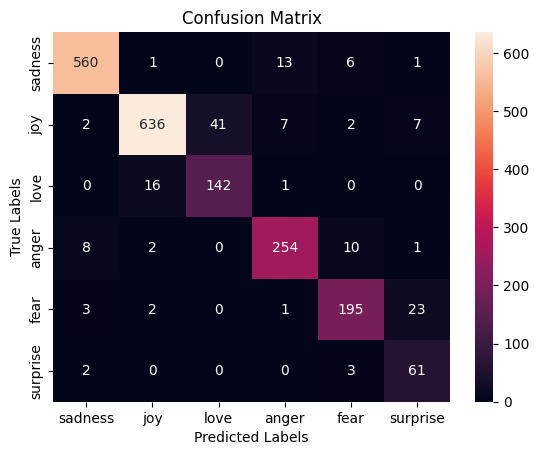

In [46]:
from sklearn.metrics import confusion_matrix
BiGRU_prediction = np.argmax(BiGRU.predict(padded_test_sequences), axis=1)
sns.heatmap(confusion_matrix(test_labels,BiGRU_prediction),annot=True,fmt='g',xticklabels=label_names,yticklabels=label_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [47]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True)

BiGRU.save(os.path.join(model_dir, 'BiGRU_model.keras'))

with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
    pickle.dump(tokenizer, file)